# $ M_B = g \times M_{DM}\times \Omega_B/\Omega_{DM}$

## Motivation
The modified NFW (mNFW) profile as decribed by Matthews & Prochaska 2017 and Prochaska & Zheng 2019 is unable to reproduce the radial profile of baryons resulting from galactic feedback in halos from simulations. Namely, Ayromlou+2023 highlight the existence of a "closure radius" $r_{close}$. $r_{close}$ is the smallest radius within which the ratio of enclosed baryon mass $M_B(<r)$ to enclosed total matter mass, $M_M(<r)$ is the cosmic mean, $\Omega_B/\Omega_M$. This implies at least two length scales, the virial radius, $r_{vir}$, and $r_{close}$ that must be encoded in any mathematical model of halo baryon density.

![alt text](Ayromlou_Fig2.png)

A second scale radius is missing in mNFW. This leads to spurious behavior when extending mNFW beyond $r_{vir}$, e.g. not enough or too much enclosed baryon mass.

The modified-modifed NWF profile (mmNFW) which attempts to resolve this by introducing an exponential correction to mNFW suffers a different flaw because it too doesn't intrinsically encode two lengthscales. Specifically, when normalizing halo baryons such that the cosmic baryon to matter average ratio is reached at a large $r_{close}$ (compared to $r_{vir}$), the enclosed mass ratio actually crosses this threshold much earlier, i.e. below $r_{vir}$, and then severely exceeds this limit between this first crossing and $r_{close}$ (See figure below).

![alt text](Lordrick_mmNFW.png)

Thus, a new baryon model framework is required that correctly encodes the behavior of the enclosed mass ratio. The $g\times M_{DM}$ model is an attempt to derive a baryon density profile that automatically respects the mass ratio constraint. Also, as a side-efect, it is generalizable to numerically model *any* baryon simulation-based radial gas profile.

## Derivation of the most general baryon profile
One begins with the assumption of a dark matter profile. This is not necessarily required to be NFW (nor is NFW even a correct assumption because of baryon back-reaction), but choosing NFW helps to illustrate the mathematics. As one sees later, the framework is generalizable to any dark matter profile. The following is merely a method to self-consistently define a baryon profile given a dark matter profile.

$
\begin{equation}
    \begin{aligned}
    \rho_{DM} &= \frac{\rho_0}{y(1+y)^2}\\
    \text{where}~y &= c r/r_{vir}\\
    \end{aligned}
\end{equation}
$

Here $\rho_0$ is the scale density and $c$ is the concentration parameter. *Note that this is only describing dark matter*. The enclosed dark matter mass, $M_{DM}$ is given by:

$
\begin{equation}
    \begin{aligned}
    M_{DM}(<y) &= \left(\frac{r_{vir}}{c}\right)^3 \int_0^y 4 \pi y'^2 \rho_{DM}(y') dy'\\
               &= \frac{4 \pi \rho_0 r_{vir}^3}{c^3} \left[ \ln(1+y) - \frac{y}{1+y} \right]\\
               &= M_{DM,0} \left[ \ln(1+y) - \frac{y}{1+y} \right]\text{, say}\\
    \end{aligned}
\end{equation}
$

We want to define a gas density profile, $\rho_B$ such that the enclosed baryon fraction, $f_B(y) = M_B(<y)/[M_{DM}(<y)+M_B(<y)]$, satisfies:

$\begin{equation}
    \begin{aligned}
    \lim_{y \to \infty} f_B(y) = \lim_{y \to \infty} \frac{M_B(<y)}{M_{DM}(<y)+M_B(<y)} &= \frac{\Omega_B}{\Omega_M}\\
    \end{aligned}
\end{equation}
$

This limit doesn't constrain the ratio at a finite radius, only that it also asymptotically approaches this value at large radius. This is not very hard to satisfy. For instance, one can trivially define:
$\begin{equation}
    \begin{aligned}
    M_B(<y) &= \frac{\Omega_B}{\Omega_M - \Omega_B} M_{DM}(<y)\\
    \end{aligned}
\end{equation}
$

And the ratio remains equal at all radii. However, this is not the observed behaviour in simulations. Instead, we want to define a generalization; a function $g(y)$ such that:

$\begin{equation}
    \begin{aligned}
    M_B(<y) &= g(y) \frac{\Omega_B}{\Omega_M - \Omega_B} M_{DM}(<y)\\
    \end{aligned}
\end{equation}
$

Where $\lim_{y \to \infty} g(y) = 1$. This guarantees that the enclosed mass ratio approaches the cosmic mean at large radius, but allows for deviations at smaller radius. To relate $g(y)$ to Ayromlou's defintion of $f_B(y)$, we can rearrange the above equation:

$\begin{equation}
    \begin{aligned}
    f_B(y) &= \frac{M_B(<y)}{M_{DM}(<y)+M_B(<y)}\\
           &= \frac{g(y) \frac{\Omega_B}{\Omega_M - \Omega_B} M_{DM}(<y)}{M_{DM}(<y) + g(y) \frac{\Omega_B}{\Omega_M - \Omega_B} M_{DM}(<y)}\\
           &= \frac{g(y) \frac{\Omega_B}{\Omega_M - \Omega_B}}{1 + g(y) \frac{\Omega_B}{\Omega_M - \Omega_B}}\\
    \therefore g(y) &= \frac{\Omega_M - \Omega_B}{\Omega_B}\frac{f_B(y)}{1 - f_B(y)}\\
    \end{aligned}
\end{equation}
$

Once the baryon mass profile is defined in terms of $g$, the baryon density profile can be derived by invoking the fundamental theorem of calculus:

$\begin{equation}
    \begin{aligned}
    M_B(<y) &= \int_0^y 4 \pi y'^2 \rho_B(y') \left(\frac{r_{vir}}{c}\right)^3 dy'\\
    \Rightarrow \frac{dM_B(<y)}{dy} &= 4 \pi y^2 \rho_B(y) \left(\frac{r_{vir}}{c}\right)^3\\
    \Rightarrow \rho_B(y) &= \frac{1}{4 \pi y^2} \frac{c^3}{r_{vir}^3} \frac{dM_B(<y)}{dy}\\
    &= \frac{1}{4 \pi y^2} \frac{c^3}{r_{vir}^3} \frac{d}{dy} \left[ g(y) \frac{\Omega_B}{\Omega_M - \Omega_B} M_{DM}(<y) \right]\\
    &= \frac{\Omega_B}{\Omega_M - \Omega_B} \frac{1}{4 \pi y^2} \frac{c^3}{r_{vir}^3} \left[\frac{dg(y)}{dy} M_{DM}(<y) + g(y) 4 \pi y^2 \rho_{DM}(y) \left(\frac{r_{vir}}{c}\right)^3 \right]\\
    &= \frac{\Omega_B}{\Omega_M - \Omega_B} \left[ \frac{1}{4 \pi y^2} \frac{c^3}{r_{vir}^3}\frac{dg(y)}{dy} M_{DM}(<y) \right] +  \frac{\Omega_B}{\Omega_M - \Omega_B} g(y) \rho_{DM}(y) \\
    \therefore \rho_B(y) &= \frac{\Omega_B}{\Omega_M - \Omega_B} g(y) \rho_{DM}(y) + \frac{\Omega_B}{\Omega_M - \Omega_B}\frac{c^3}{4 \pi r_{vir}^3} \left[\frac{1}{y^2} \frac{dg(y)}{dy} M_{DM}(<y) \right]\\
    \end{aligned}
\end{equation}
$

### Functional properties of $g$
As one can see, the final form of the baryon profile is agnostic to the specific dark matter profile assumed and to $g(y)$. The only requirement is that one can compute the enclosed mass profile and density profile of the dark matter. Thus, this framework can be used to define baryon profiles for any dark matter profile, not just NFW. The form of this equation should also make sense. The first term is simply a scaled version of the dark matter profile modulated by $g(y)$. This is, in a sense, similar to mnNFW or mmNFW. The second term can be thought of as a "correction" to ensure the proper behaviour of the enclosed mass fraction. If $g(y)$ is constant, this term vanishes and one recovers the trivial solution where the baryon profile is simply a scaled version of the dark matter profile. Indeed, as $g(y) \to 1$ at large radius, $dg/dy$ must tend to 0 faster than $M_{DM}(<y)/y^2$ grows to $\infty$. So, this term also vanishes and the baryon profile asymptotically approaches a scaled dark matter profile.

Sunil notes: One might have started out with a dark matter density profile and modulated it with a radial function instead of starting with enclosed mass profiles. I have a feeling that the integration by parts would yield a functional form that is not as clean but also hard to programmatically implement. The intrepid reader might wish to verify this.

## Specific examples

### Simple toy model without any interior overdensity of baryons
For illustrative purposes, let us assume that the dark matter profile is indeed NFW. Additionally, let us impose a new constraint on the enclosed mass ratio. Namely, that it should always be less than the cosmic mean, i.e.
$\begin{equation}
    \begin{aligned}
    \frac{M_B(<y)}{M_{DM}(<y)+M_B(<y)} &< \frac{\Omega_B}{\Omega_M}~\forall y\\
    \end{aligned}
\end{equation}
$

This is actually achieved in TNG for halos of mass $\lesssim 10^{10} M_\odot$ as illustrated by Ayromlou+2023 (Fig. 2). This would imply:
$\begin{equation}
    \begin{aligned}
    \frac{g(y) M_{DM}(<y)\Omega_B/(\Omega_M-\Omega_B)}{M_{DM}(<y)+g(y) M_{DM}(<y)\Omega_B/(\Omega_M-\Omega_B)} &< \frac{\Omega_B}{\Omega_M}~\forall y\\
    \Rightarrow \frac{g(y)\Omega_B/(\Omega_M-\Omega_B)}{1+g(y)\Omega_B/(\Omega_M-\Omega_B)} &< \frac{\Omega_B}{\Omega_M}~\forall y\\
    \Rightarrow \frac{g(y)\Omega_B}{\Omega_M-(1-g(y))\Omega_B} &< \frac{\Omega_B}{\Omega_M}~\forall y\\
    \Rightarrow \frac{g(y)}{1-(1-g(y))\frac{\Omega_B}{\Omega_M}} &< 1~\forall y\\
    \Rightarrow g(y) &< 1~\forall y\\
    \end{aligned}
\end{equation}
$

A function that works is $g(y) = \tanh(y/y_{out})$. Here, $y_{out} = c r_{out}/r_{vir}$ where $r_{out}$ is a scale radius beyond which the enclosed mass ratio asymptotes to the cosmic mean. i.e. the enclosed baryon mass is:

$\begin{equation}
    \begin{aligned}
    M_B(<y) &= \tanh\left(\frac{y}{y_{out}}\right) \frac{\Omega_B}{\Omega_M - \Omega_B} M_{DM}(<y)\\
            &= \tanh\left(\frac{y}{y_{out}}\right) \frac{\Omega_B}{\Omega_M - \Omega_B} M_{DM,0} \left[ \ln(1+y) - \frac{y}{1+y} \right]\\
            &= M_{B,0}\tanh\left(\frac{y}{y_{out}}\right)\left[ \ln(1+y) - \frac{y}{1+y} \right] \text{, say}\\
    \end{aligned}
\end{equation}
$

Thus the corresponding baryon density profile is:
$\begin{equation}
    \begin{aligned}
    \rho_B(y) &= \frac{\Omega_B}{\Omega_M - \Omega_B} \tanh\left(\frac{y}{y_{out}}\right) \rho_{DM}(y) + \frac{\Omega_B}{\Omega_M - \Omega_B}\frac{c^3}{4 \pi r_{vir}^3} \left[\frac{1}{y^2} \frac{d}{dy}\left(\tanh\left(\frac{y}{y_{out}}\right)\right) M_{DM}(<y) \right]\\
    &= \frac{\Omega_B}{\Omega_M - \Omega_B} \tanh\left(\frac{y}{y_{out}}\right) \rho_{DM}(y) + \frac{\Omega_B}{\Omega_M - \Omega_B}\frac{c^3}{4 \pi r_{vir}^3} \left[\frac{1}{y^2} \frac{\text{sech}^2\left(\frac{y}{y_{out}}\right)}{y_{out}} M_{DM}(<y) \right]\\
    \end{aligned}
\end{equation}
$

Substituting Eqn. 2 for the NFW enclosed mass and the NFW density profile, one obtains the final form of the baryon density profile:

$\begin{equation}
    \begin{aligned}
    \rho_B(y) &= \frac{\Omega_B}{\Omega_M - \Omega_B} \tanh\left(\frac{y}{y_{out}}\right) \frac{\rho_0}{y(1+y)^2} + \frac{\Omega_B}{\Omega_M - \Omega_B}\frac{c^3}{4 \pi r_{vir}^3} \left[\frac{1}{y^2} \frac{\text{sech}^2\left(\frac{y}{y_{out}}\right)}{y_{out}} M_{DM,0} \left[ \ln(1+y) - \frac{y}{1+y} \right] \right]\\
    &= \frac{\Omega_B}{\Omega_M - \Omega_B} \tanh\left(\frac{y}{y_{out}}\right) \frac{\rho_0}{y(1+y)^2} + \frac{\Omega_B}{\Omega_M - \Omega_B}\frac{\rho_0}{y_{out}} \text{sech}^2\left(\frac{y}{y_{out}}\right)  \left[ \frac{\ln(1+y)}{y^2} - \frac{1}{y(1+y)} \right]\\
    &= \rho_0 \frac{ \Omega_B}{\Omega_M - \Omega_B} \left[ \tanh\left(\frac{y}{y_{out}}\right) \frac{1}{y(1+y)^2} + \frac{1}{y_{out}} \text{sech}^2\left(\frac{y}{y_{out}}\right)  \left( \frac{\ln(1+y)}{y^2} - \frac{1}{y(1+y)} \right) \right]\\
    \end{aligned}
\end{equation}
$

While this example is not strictly illustrating a "closure" radius, it does show an outer scale radius within which a large fraction of the baryons are contained, and beyond which the enclosed mass ratio asymptotes to the cosmic mean. More complex forms of $g(y)$ can be constructed to explicitly encode a closure radius as well. Indeed, with this general framework, one can numerically construct the baryon density profile corresponding to any dark matter profile and a radial $f_B{<y}$ profile taken from simulations.


In [1]:
from astropy.cosmology import Planck18 as cosmo
from astropy.table import Table

from scipy.interpolate import CubicSpline, InterpolatedUnivariateSpline as IUS, make_interp_spline as MIS
from scipy.differentiate import derivative

import numpy as np

import matplotlib.pyplot as plt

In [2]:
Omega_ratio = cosmo.Ob0 / (cosmo.Om0 - cosmo.Ob0)
 
# Example y values from 0.1 to 100. Remember, y = r/r_s. Here r_s, the scale radius, is r_vir/c.
# So for a halo with c = 7.67, y = 5 corresponds to r = r_vir * 5/7.67 ~ 0.65 r_vir
# and y = 5*7.67 = 38.35 corresponds to r = 5 r_vir
y_array = np.logspace(-1, 2, 100)

def nfw_profile(y):
    return 1 / (y * (1 + y)**2)

def mass_enclosed_nfw(y):
    return 4*np.pi*(np.log(1 + y) - y / (1 + y)) 

def grape_nfw(y, y_out):
    return Omega_ratio *(nfw_profile(y)*  np.tanh(y/y_out) + mass_enclosed_nfw(y)*1/np.cosh(y/y_out)**2/(y_out*y**2)/4/np.pi)

def mass_enclosed_grape(y, y_out):
    return Omega_ratio * np.tanh(y/y_out) * mass_enclosed_nfw(y)

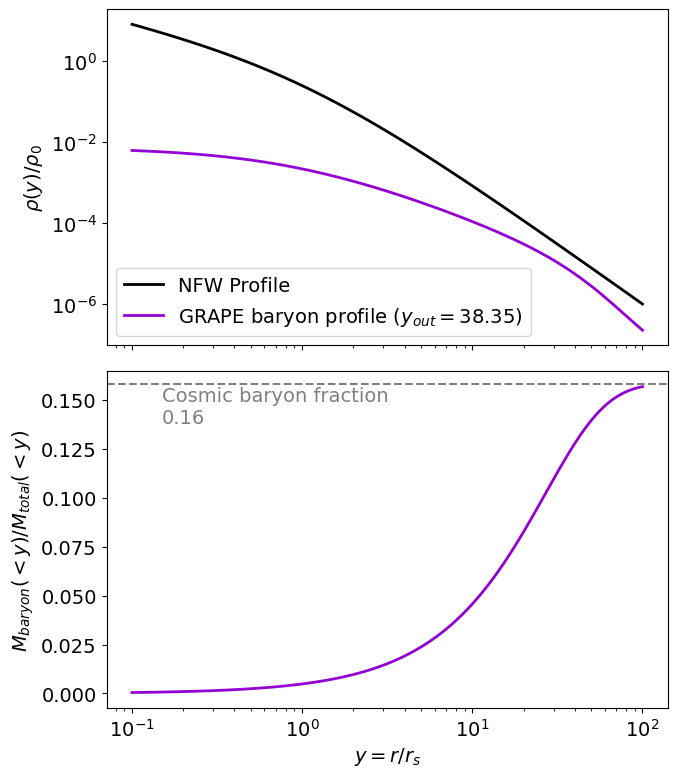

In [3]:
plt.rcParams.update({'font.size': 14})
.3
fig, axs = plt.subplots(figsize=(7,8), nrows=2, sharex=True, tight_layout=True)

ax = axs[0]
ax.loglog(y_array, nfw_profile(y_array), "k", lw=2, label='NFW Profile')
ax.loglog(y_array, grape_nfw(y_array, 38.35), "darkviolet", lw=2, label=r'GRAPE baryon profile ($y_{out}=38.35$)')
ax.set_ylabel(r'$\rho(y)/\rho_{0}$')
ax.legend()

ax = axs[1]
ax.semilogx(y_array,
            mass_enclosed_grape(y_array, 38.35)/(mass_enclosed_nfw(y_array) + mass_enclosed_grape(y_array, 38.35)),
            "darkviolet", lw=2)
ax.set_ylabel(r'$M_{baryon}(<y)/M_{total}(<y)$')
ax.set_xlabel(r"$y = r/r_{s}$")
ax.axhline(cosmo.Ob0/cosmo.Om0, color='gray', ls='--')
ax.annotate(f'Cosmic baryon fraction\n{cosmo.Ob0/cosmo.Om0:.2f}', xy=(0.15, cosmo.Ob0/cosmo.Om0 - 0.02), color='gray')
plt.show()

### Adding an interior overdensity

For curves like the IllustrisTNG12 profile shown in Ayromlou+2023 Fig. 2, one can see that there is an interior overdensity of baryons within $\sim 2 r_{200}$. To model this, one can define a $g(y)$ that exceeds 1 at small radius, but asymptotes to 1 at large radius. In this case, it makes much more sense to start with the $f_B(y)$ profile taken from the simulation data, and then compute $g(y)$ using the relation derived earlier:
$\begin{equation}
    \begin{aligned}
    g(y) &= \frac{\Omega_M - \Omega_B}{\Omega_B}\frac{f_B(y)}{1 - f_B(y)}\\
    \end{aligned}
\end{equation}
$

So, let's say $f_B(y) = A/\sqrt{2\pi}\sigma\exp{\left(-\frac{(y-\mu)^2}{2\sigma^2}\right)} + (\Omega_b/\Omega_M) \tanh{(y/y_{out})}$. This looks like:

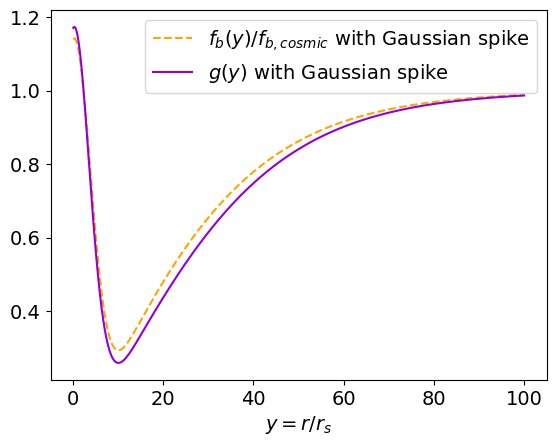

In [ ]:
def f_b_gaussian_spike(y, A, sigma, mu, y_out):
    return A * np.exp(-0.5 * ((y - mu)/sigma)**2) + cosmo.Ob0/cosmo.Om0 * np.tanh(y/y_out)

def g_from_fb(y, f_b_func, **fb_args):
    return f_b_func(y, **fb_args) / (1 - f_b_func(y, **fb_args))/Omega_ratio

def g_gaussian_spike(y, A, sigma, mu, y_out):
    return g_from_fb(y, f_b_gaussian_spike, A=A, sigma=sigma, mu=mu, y_out=y_out)

def mass_enclosed_gaussian_spike(y, A, sigma, mu, y_out):
    return Omega_ratio * g_gaussian_spike(y, A, sigma, mu, y_out) * mass_enclosed_nfw(y)


plt.plot(y_array, f_b_gaussian_spike(y_array, A=0.18, sigma=0.5*7.67, mu=0, y_out=38.35)/cosmo.Ob0*cosmo.Om0,
         color="orange", ls="--", label=rf'$f_b(y)/f_{{b,cosmic}}$ with Gaussian spike')
plt.plot(y_array, g_from_fb(y_array, f_b_gaussian_spike, A=0.18, sigma=0.5*7.67, mu=0, y_out=38.35),
         color="darkviolet", label=r'$g(y)$ with Gaussian spike')
plt.xlabel(r"$y = r/r_{s}$")
#plt.ylabel(r"$g(y)~or~f_b(y)/f_{b,cosmic}$")
plt.legend()
plt.show()

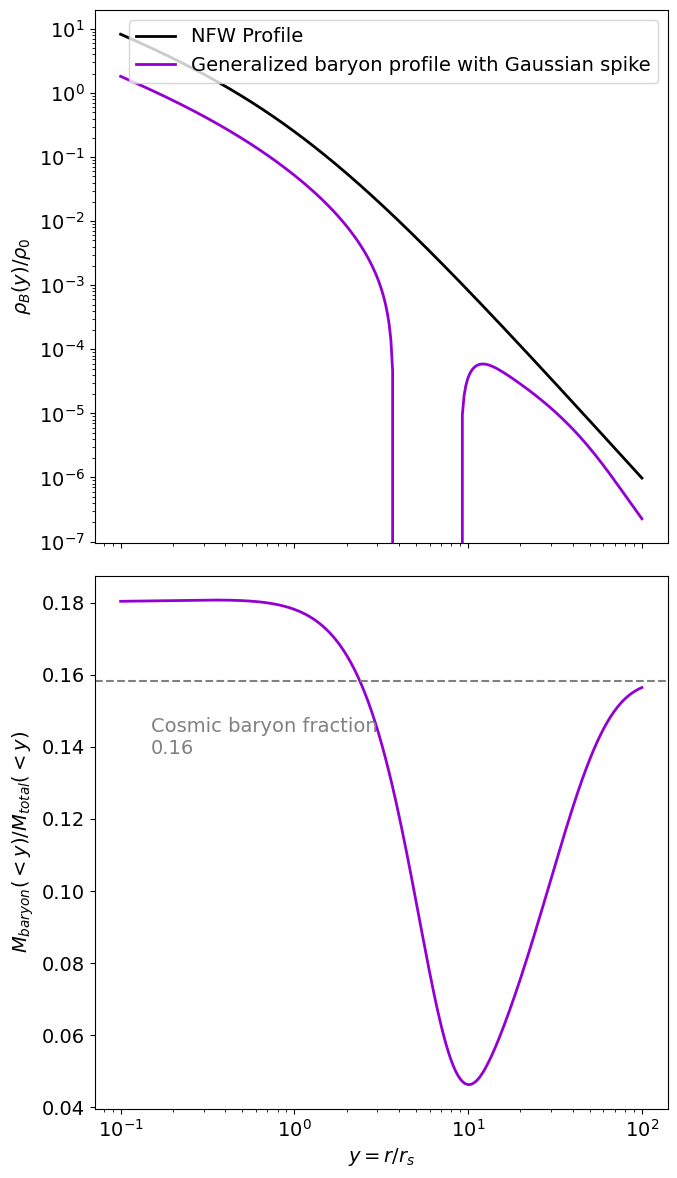

In [107]:
# Now define a baryon profile for a general g(y)

def grape_gaussian_spike(y, g_args={},
                               rho_dm_func=nfw_profile, rho_dm_args={},
                               M_dm_func=mass_enclosed_nfw, M_dm_args={}):
    
    # the way the following is defined, it's effectively rho_b/rho_0.
    return Omega_ratio * rho_dm_func(y, **rho_dm_args) * g_gaussian_spike(y, **g_args) + \
           Omega_ratio * derivative(g_gaussian_spike, y, args = [g_args['A'], g_args['sigma'], g_args['mu'], g_args['y_out']]).df * M_dm_func(y, **M_dm_args) / (4 * np.pi * y**2)

# Plot this out for the Gaussian spike case

y_array = np.logspace(-1, 2, 300)

fig, axs = plt.subplots(figsize=(7,12), nrows=2, sharex=True, tight_layout=True)

ax = axs[0]

ax.loglog(y_array, nfw_profile(y_array), "k", lw=2, label='NFW Profile')
ax.loglog(y_array,
         grape_gaussian_spike(y_array, g_args={'A': 0.18, 'sigma': 0.5*7.67, 'mu': 0, 'y_out': 38.35}),
         color="darkviolet", lw=2, label=r'Generalized baryon profile with Gaussian spike')
ax.set_ylabel(r"$\rho_B(y)/\rho_{0}$")
ax.legend(loc='upper right')

ax = axs[1]
ax.semilogx(y_array,
                mass_enclosed_gaussian_spike(y_array, A=0.18, sigma=0.5*7.67, mu=0, y_out=38.35)/
                (mass_enclosed_nfw(y_array) + mass_enclosed_gaussian_spike(y_array, A=0.18, sigma=0.5*7.67, mu=0, y_out=38.35)),
                color="darkviolet", lw=2)
ax.set_ylabel(r'$M_{baryon}(<y)/M_{total}(<y)$')
ax.set_xlabel(r"$y = r/r_{s}$")
ax.axhline(cosmo.Ob0/cosmo.Om0, color='gray', ls='--')
ax.annotate(f'Cosmic baryon fraction\n{cosmo.Ob0/cosmo.Om0:.2f}', xy=(0.15, cosmo.Ob0/cosmo.Om0 - 0.02), color='gray') 
plt.show()

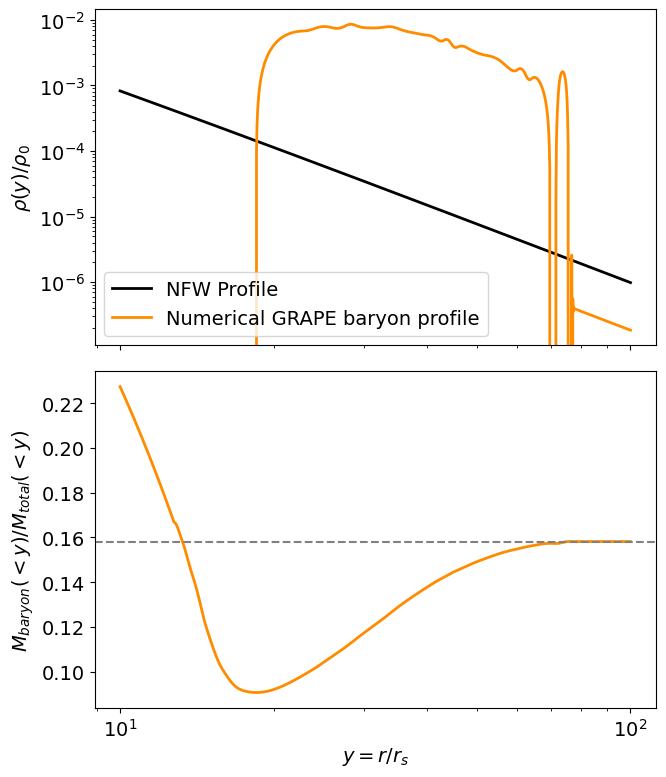

In [11]:
# Read from Ayromlou's table.
ayromlou_tab = Table.read("~/Desktop/FRB/mmnfw/f_b_illustris_12.csv", format='csv')
ayromlou_tab.sort('r/r_200')
c = 7.67
y_12 = ayromlou_tab['r/r_200'] * c
f_b_12 = ayromlou_tab['f_b']*cosmo.Ob0/cosmo.Om0
# create an interpolation function for g(y)

def add_boundary_knots(spline):
    """
    Add knots infinitesimally to the left and right.

    Additional intervals are added to have zero 2nd and 3rd derivatives,
    and to maintain the first derivative from whatever boundary condition
    was selected. The spline is modified in place.
    """
    # determine the slope at the left edge
    leftx = spline.x[0]
    lefty = spline(leftx)
    leftslope = spline(spline.x[1], nu=1)

    # add a new breakpoint just to the left and use the
    # known slope to construct the PPoly coefficients.
    leftxnext = np.nextafter(leftx, leftx - 1)
    leftynext = lefty + leftslope*(leftxnext - leftx)
    leftcoeffs = np.array([0, 0, leftslope, leftynext])
    spline.extend(leftcoeffs[..., None], np.r_[leftxnext])

    # repeat with additional knots to the right
    rightx = spline.x[-1]
    righty = spline(rightx)
    rightslope = spline(rightx,nu=1)
    rightxnext = np.nextafter(rightx, rightx + 1)
    rightynext = righty + rightslope * (rightxnext - rightx)
    rightcoeffs = np.array([0, 0, rightslope, rightynext])
    spline.extend(rightcoeffs[..., None], np.r_[rightxnext])

f_b_interp = CubicSpline(y_12, f_b_12, bc_type='clamped')
#f_b_mis = MIS(y_12, f_b_12, bc_type=([(1, 0.0)], [(1, 0.0)]))
add_boundary_knots(f_b_interp)

y_array = np.logspace(1, 2, 1000)
g_y = f_b_interp(y_array) / (1 - f_b_interp(y_array))/Omega_ratio
g_y_interp = CubicSpline(y_array, g_y, bc_type='clamped')
add_boundary_knots(g_y_interp)


# Define the grape profile given this new g(y)
def grape_nfw_numerical(y, g_y_interp):
    return Omega_ratio *(nfw_profile(y)*  g_y_interp(y) + mass_enclosed_nfw(y)*derivative(g_y_interp, y).df/4/np.pi)

def mass_enclosed_grape_numerical(y, g_y_interp):
    return Omega_ratio * g_y_interp(y) * mass_enclosed_nfw(y)

# Plot the new profile
fig, axs = plt.subplots(figsize=(7,8), nrows=2, sharex=True, tight_layout=True)
ax = axs[0]
ax.loglog(y_array, nfw_profile(y_array), "k", lw=2, label='NFW Profile')
ax.loglog(y_array, grape_nfw_numerical(y_array, g_y_interp), "darkorange", lw=2, label='Numerical GRAPE baryon profile')
ax.set_ylabel(r'$\rho(y)/\rho_{0}$')
ax.legend()

ax = axs[1]
ax.semilogx(y_array,
            mass_enclosed_grape_numerical(y_array, g_y_interp)/(mass_enclosed_nfw(y_array) + mass_enclosed_grape_numerical(y_array, g_y_interp)),
            "darkorange", lw=2)
ax.set_ylabel(r'$M_{baryon}(<y)/M_{total}(<y)$')
ax.set_xlabel(r"$y = r/r_{s}$")
ax.axhline(cosmo.Ob0/cosmo.Om0, color='gray', ls='--')
ax.annotate(f'Cosmic baryon fraction\n{cosmo.Ob0/cosmo.Om0:.2f}', xy=(0.15, cosmo.Ob0/cosmo.Om0 - 0.02), color='gray')
plt.show()

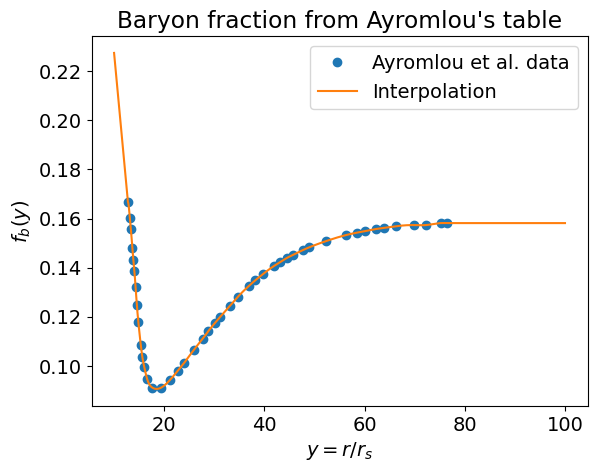

In [10]:
def add_boundary_knots(spline):
    """
    Add knots infinitesimally to the left and right.

    Additional intervals are added to have zero 2nd and 3rd derivatives,
    and to maintain the first derivative from whatever boundary condition
    was selected. The spline is modified in place.
    """
    # determine the slope at the left edge
    leftx = spline.x[0]
    lefty = spline(leftx)
    leftslope = spline(spline.x[1], nu=1)

    # add a new breakpoint just to the left and use the
    # known slope to construct the PPoly coefficients.
    leftxnext = np.nextafter(leftx, leftx - 1)
    leftynext = lefty + leftslope*(leftxnext - leftx)
    leftcoeffs = np.array([0, 0, leftslope, leftynext])
    spline.extend(leftcoeffs[..., None], np.r_[leftxnext])

    # repeat with additional knots to the right
    rightx = spline.x[-1]
    righty = spline(rightx)
    rightslope = spline(rightx,nu=1)
    rightxnext = np.nextafter(rightx, rightx + 1)
    rightynext = righty + rightslope * (rightxnext - rightx)
    rightcoeffs = np.array([0, 0, rightslope, rightynext])
    spline.extend(rightcoeffs[..., None], np.r_[rightxnext])

g_y = f_b_12/(1 - f_b_12)/Omega_ratio
f_b_interp = CubicSpline(y_12, f_b_12, bc_type='clamped')
#f_b_mis = MIS(y_12, f_b_12, bc_type=([(1, 0.0)], [(1, 0.0)]))
add_boundary_knots(f_b_interp)

plt.plot(y_12, f_b_12, 'o', label='Ayromlou et al. data')
plt.plot(y_array, f_b_interp(y_array), label='Interpolation')
#plt.plot(y_array, f_b_mis(y_array), label='f_b(y) from MIS spline')
plt.xlabel(r"$y = r/r_{s}$")
plt.ylabel(r"$f_b(y)$")
plt.title("Baryon fraction from Ayromlou's table")
plt.legend()
plt.show()

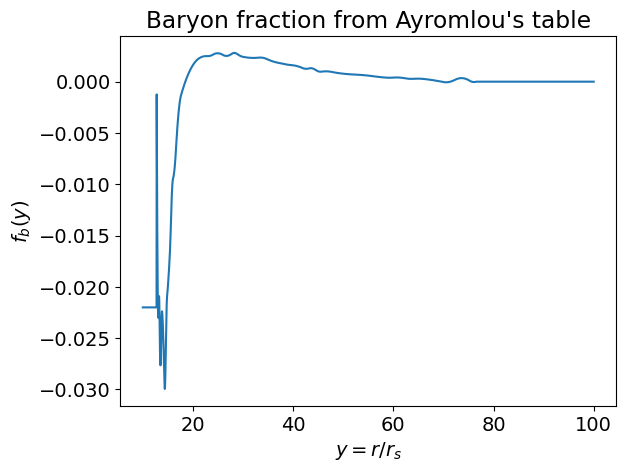

In [100]:
plt.plot(y_array, f_b_interp(y_array, nu =1), label='f_b(y) from Ayromlou et al. data')
plt.xlabel(r"$y = r/r_{s}$")
plt.ylabel(r"$f_b(y)$")
plt.title("Baryon fraction from Ayromlou's table")
plt.show()